# Annotation: from noisy single trials to validated event boxes

There is no public motor imagery EEG dataset with bounding-box annotations, so every box in this project is
generated automatically from time-frequency maps. Automatic labels are only useful if they mark real,
cue-locked brain activity rather than spontaneous fluctuations. This notebook documents how the labeling
rule was validated and why the final images are **averages of 5 trials**:

1. **Single-trial diagnosis (k = 1):** a fixed ±20 % threshold, a statistical (z-score) threshold, and a
   phase-randomized surrogate test.
2. **k-trial groups:** the same surrogate test on averages of k trials, used to choose k and the z threshold.
3. **Final dataset:** example boxes, statistics, trial overlap between groups, and agreement with the cue.

A manual quality check of 50 random images closes the notebook.
All numbers below are read from `results/tables/`; the code that produced them lives in `src/autolabel.py`
and `src/groups.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.utils.coords import CLASSES_5, F_MAX, F_MIN, PANEL_H, PANEL_ORDER, T_MAX, T_MIN
from src.utils.io import load_config, resolve

T = resolve("results/tables")
F = resolve("results/figures")
pd.set_option("display.precision", 2)

## 1. Single-trial labels (k = 1)

### 1.1 The ±20 % threshold flags almost everything

The original rule marked ERD where the single-trial power dropped ≥ 20 % below its own
pre-cue baseline, and assigned the class from the cue. The table shows how often at least one ERD
candidate box appears on each panel, by cue class (session T). If the labels were location-specific,
the diagonal (C4 for left hand, C3 for right hand, Cz for feet, C5/C6 for tongue) would stand out.
It does not: ERD candidates appear on every panel in ~85–97 % of trials.

In [2]:
spec = pd.read_csv(T / "autolabel_variants_specificity.csv")
spec[spec["variant"] == "V0_concept"].drop(columns="variant").set_index("cue_class")

,C5,C3,Cz,C4,C6
cue_class,,,,,
ERD_left_hand,0.95,0.96,0.96,0.95,0.97
ERD_right_hand,0.97,0.96,0.95,0.93,0.96
ERD_feet,0.93,0.90,0.90,0.89,0.96
ERD_tongue,0.92,0.87,0.91,0.85,0.92


Fifteen variants of the rule (smoothing, minimum duration, largest component per panel, contralateral
dominance, z-score thresholds) were compared. The share of ERD boxes that fall on the panel expected from
the cue stays near the chance level of ~25 % for all of them.

In [3]:
var = pd.read_csv(T / "autolabel_variants.csv")
var[["variant", "smoothing", "threshold", "dominance", "erd_valid_panel_pct", "background_pct",
     "ers_per_image", "noise_base_erd_pct"]].set_index("variant")

,smoothing,threshold,dominance,erd_valid_panel_pct,background_pct,ers_per_image,noise_base_erd_pct
variant,,,,,,,
V0_concept,2.0 Hz x 0.4 s,percent -20.0/20.0,False,24.63,0.00,5.92,11.88
V1_pct,1.5 Hz x 0.15 s,percent -20.0/20.0,False,25.14,0.00,4.43,30.64
V2_pct_dom,1.5 Hz x 0.15 s,percent -20.0/20.0,True,27.42,0.00,4.43,30.64
V3_z2,1.5 Hz x 0.15 s,zscore[percent] k=2.0,False,27.26,1.12,3.25,30.64
V4_z2.5,1.5 Hz x 0.15 s,zscore[percent] k=2.5,False,54.17,4.42,2.85,30.64
V5_z3,1.5 Hz x 0.15 s,zscore[percent] k=3.0,False,NaN,7.69,2.48,30.64
V6_z2_dom,1.5 Hz x 0.15 s,zscore[percent] k=2.0,True,27.69,1.20,3.25,30.64
V7_z2.5_dom,1.5 Hz x 0.15 s,zscore[percent] k=2.5,True,54.93,4.42,2.85,30.64
V8_z3_dom,1.5 Hz x 0.15 s,zscore[percent] k=3.0,True,NaN,7.69,2.48,30.64


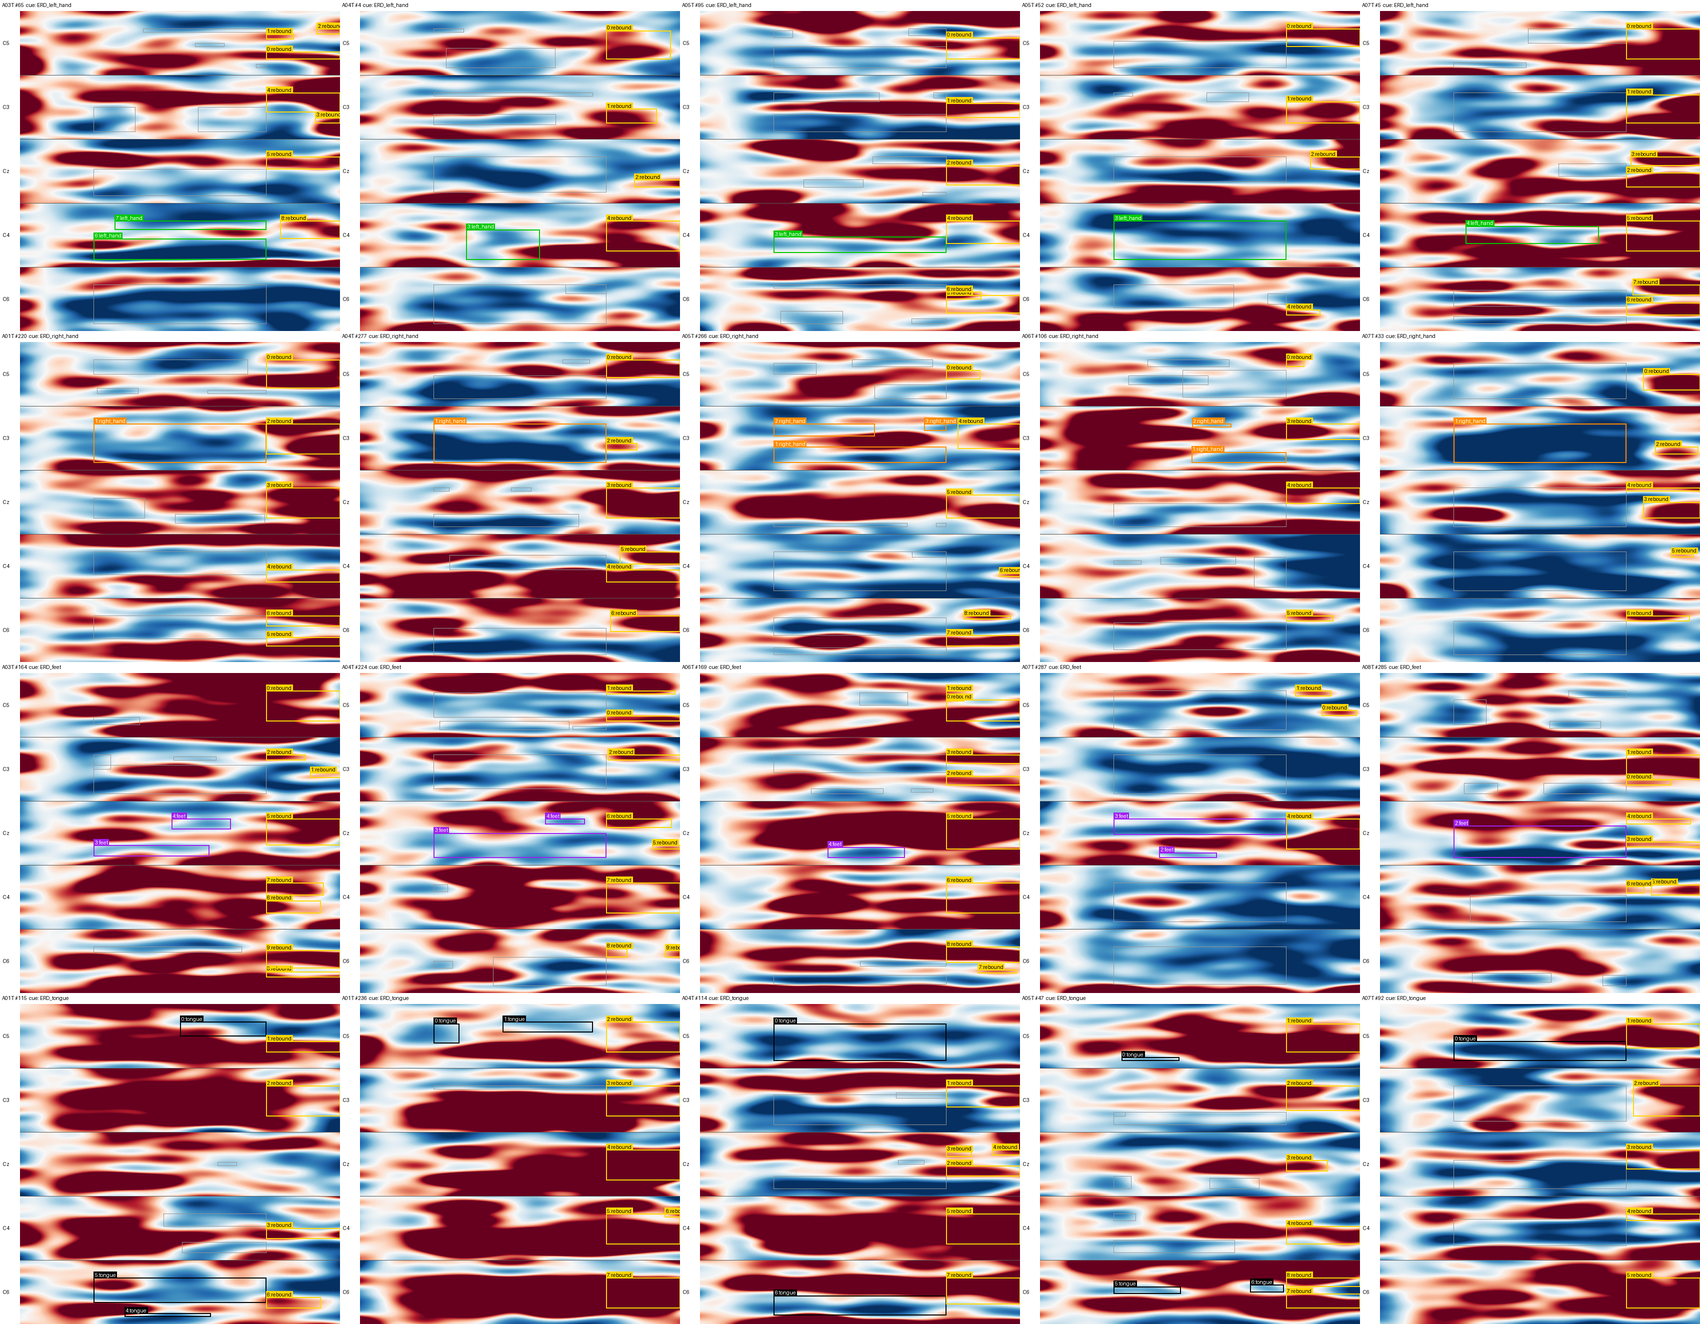

In [4]:
display(Image(filename=str(F / "autolabel_variants" / "V0_concept.png"), width=900))

### 1.2 A z-score computed on baseline-corrected maps is inflated

A statistical threshold (z relative to the pre-cue distribution) looks like the natural fix. But when z is
computed from maps that were already baseline-corrected **per trial**, the baseline window is forced to
average zero and its spread is underestimated. After the cue the spread is ~2.4× larger, even in surrogate
data without any event, so |z| ≥ 3 is reached far too often. The corrected scale, `session_db`, z-scores
absolute dB power against the baseline pixels of all trials of the session; its post-cue / baseline spread
ratio is ~0.93.

In [5]:
pd.read_csv(T / "k1_label_null_sd_ratio.csv").pivot(index="mode", columns="data", values="sd_post_over_sd_base")

data,real,surrogate
mode,,
session_db,0.92,0.93
trial_db,2.40,2.04


### 1.3 Surrogate test on single trials

Surrogates keep the amplitude spectrum of every epoch and channel but randomize the Fourier phases
(Theiler et al., 1992), which removes cue-locked events. The identical pipeline is then applied. A label
rule is trusted only if real data produce clearly more boxes than surrogates; the criterion used here is
**≥ 3× per class**. Subjects A01–A03, session T.

In [6]:
k1 = pd.read_csv(T / "k1_label_null_test.csv")
ratio_cols = [f"{c}_ratio" for c in CLASSES_5]
k1[["mode", "z", "background_pct_real", "background_pct_surrogate"] + ratio_cols].set_index(["mode", "z"])

background_pct_real  background_pct_surrogate  ERD_C4_ratio  \
mode       z                                                                  
session_db 2.5                62.36                     79.09          1.77   
           3.0                82.66                     95.33          2.67   
           3.5                93.60                     98.77          2.00   
           4.0                97.42                     99.26           inf   
trial_db   2.5                 0.00                      0.00          0.82   
           3.0                 0.25                      0.00          0.91   
           3.5                 1.48                      1.72          0.93   
           4.0                 4.92                     10.46          1.19   

                ERD_C3_ratio  ERD_Cz_ratio  ERD_lateral_ratio  \
mode       z                                                    
session_db 2.5          2.61          1.45               0.48   
           3.0         15.33          0.78               0.38   
           3.5          7.33          0.00               0.25   
           4.0           inf          0.00               0.00   
trial_db   2.5          0.94          0.97               0.81   
           3.0          1.08          1.13               0.81   
           3.5          1.35          1.29               0.85   
           4.0          1.74          1.40               0.96   

                ERS_rebound_ratio  
mode       z                       
session_db 2.5               2.17  
           3.0               3.91  
           3.5               8.00  
           4.0               9.50  
trial_db   2.5               1.10  
           3.0               1.16  
           3.5               1.21  
           4.0               1.38

With the inflated scale (`trial_db`) real and surrogate data are indistinguishable at every z. With
`session_db`, the smallest z that keeps surrogate false positives ≤ 10 % per class is 2.5, and there no class
reaches 3×. **Conclusion (Q0): single-trial ERD cannot be labeled reliably with an automatic rule.**

## 2. Averages of k trials

Averaging power over k trials with the same cue reduces spontaneous fluctuations roughly by √k while the
cue-locked ERD stays. The figure shows five single trials and their average, all on the final z scale
(`session_db`, smoothed, z −4…+4) for one right-hand group of subject A03: single trials are dominated by
blobs of both signs, while the average shows a coherent ERD on C3.

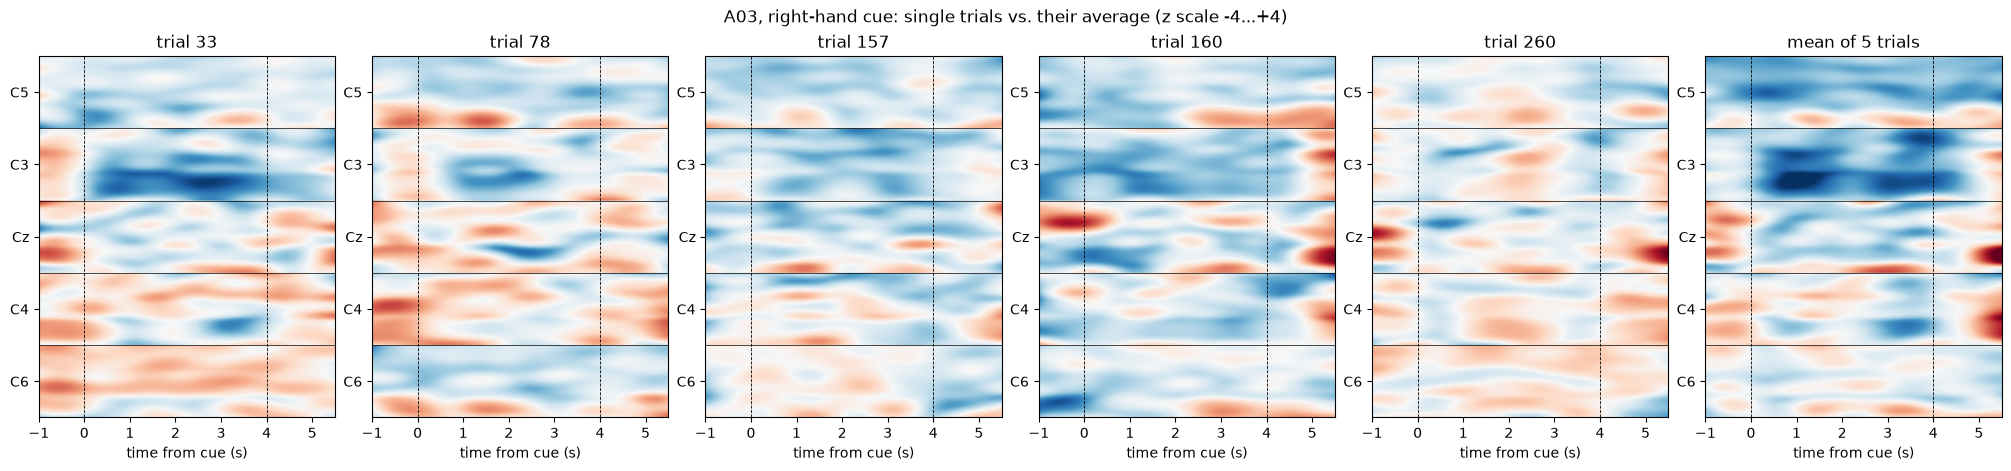

In [7]:
from src.data import crop_times, render_erd, smooth
from src.groups import file_power, group_power, make_groups, session_z

gcfg = load_config("configs/groups.yaml")
pcfg = load_config("configs/preprocess.yaml")
meta = pd.read_csv(resolve(pcfg["paths"]["processed_dir"]) / "metadata.csv", keep_default_na=False)
meta = meta[(meta["subject"] == "A03") & (meta["session"] == "T")]
times = crop_times(pcfg)
tidx, power = file_power("A03", "T", pcfg)
sp = smooth(power, pcfg)
del power
groups = make_groups(meta, gcfg["k"], gcfg["n_groups"], gcfg["seed"])
g = groups[(groups["split"] == "train") & (groups["class_name"] == "right_hand")].iloc[[3]]
members = pd.DataFrame({"trials": g["trials"].iloc[0].split(";")})
single_all = session_z(sp, times, [-1.0, 0.0])  # single-trial z (statistics from all single trials)
pos = {t: i for i, t in enumerate(tidx)}
z_single = single_all[[pos[int(t)] for t in members["trials"]]]
z_group = session_z(group_power(sp, tidx, groups), times, [-1.0, 0.0])[groups.index.get_loc(g.index[0])]
rcfg = dict(pcfg, render=gcfg["render"])

fig, axes = plt.subplots(1, 6, figsize=(20, 4.6), constrained_layout=True)
for ax, z, title in zip(axes, list(z_single) + [z_group],
                        [f"trial {t}" for t in members["trials"]] + ["mean of 5 trials"]):
    ax.imshow(render_erd(z, rcfg), extent=[T_MIN, T_MAX, 640, 0], aspect="auto")
    ax.set_yticks([(p + 0.5) * PANEL_H for p in range(5)], PANEL_ORDER)
    for p in range(1, 5):
        ax.axhline(p * PANEL_H, color="k", lw=0.5)
    for t in (0, 4):
        ax.axvline(t, color="k", ls="--", lw=0.6)
    ax.set_title(title)
    ax.set_xlabel("time from cue (s)")
fig.suptitle("A03, right-hand cue: single trials vs. their average (z scale -4...+4)")
fig.savefig(F / "single_trial_vs_group.png", dpi=110)
plt.show()

### 2.1 Choosing k and z with the surrogate test

The surrogates are averaged exactly like the real trials (same group composition). The first table is the
grid search (k ∈ {5, 10}, z ∈ {2.5, 3}, with the contralateral dominance rule that was used at that point);
the second is the final rule without dominance. k = 5 is the smallest k that passes; z = 3 gives a clear
margin for every class (z = 2.5 passes only at the margin for `ERD_lateral` and `ERS_rebound`).

In [8]:
grid = pd.read_csv(T / "kavg_dom_label_null_test.csv")
display(grid[["k", "z", "background_pct_real", "background_pct_surrogate"] + ratio_cols].set_index(["k", "z"]))
final = pd.read_csv(T / "kavg_label_null_test.csv")
final[["k", "z", "background_pct_real", "background_pct_surrogate"] + ratio_cols
      + [f"{c}_img_with_pct_surr" for c in CLASSES_5]].set_index(["k", "z"])

background_pct_real  background_pct_surrogate  ERD_C4_ratio  \
k  z                                                                  
5  2.5                33.55                     72.05          3.42   
   3.0                55.90                     93.46         15.07   
10 2.5                22.60                     65.77          4.12   
   3.0                40.97                     89.89         12.28   

        ERD_C3_ratio  ERD_Cz_ratio  ERD_lateral_ratio  ERS_rebound_ratio  
k  z                                                                      
5  2.5          3.53          3.21               3.00               3.09  
   3.0         11.63         11.64               5.63               5.20  
10 2.5          4.77          4.01               3.04               4.01  
   3.0         15.06         18.11               5.58               8.15

,,background_pct_real,background_pct_surrogate,ERD_C4_ratio,ERD_C3_ratio,ERD_Cz_ratio,ERD_lateral_ratio,ERS_rebound_ratio,ERD_C4_img_with_pct_surr,ERD_C3_img_with_pct_surr,ERD_Cz_img_with_pct_surr,ERD_lateral_img_with_pct_surr,ERS_rebound_img_with_pct_surr
k,z,,,,,,,,,,,,
5,3.0,56.25,93.47,22.2,13.14,16.73,11.5,5.34,0.69,1.3,0.69,1.25,3.61


Note: the two settings are not run under identical conditions. The k = 1 bars come from subjects A01–A03 and
still used the contralateral dominance rule; the final bars use all 9 subjects without dominance. The gap
between them is far larger than this difference.

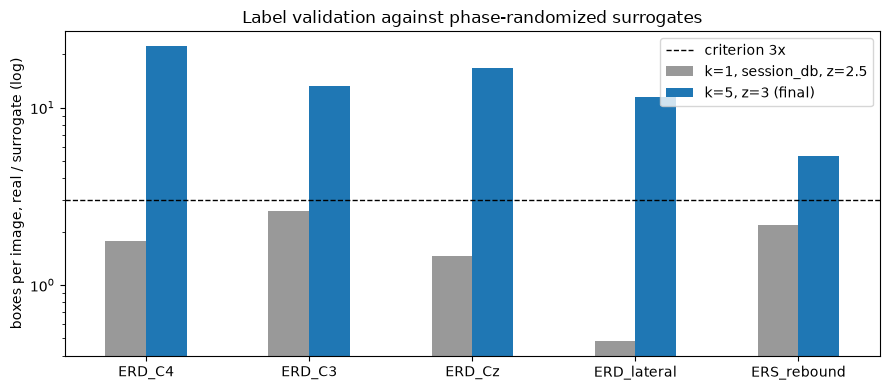

In [9]:
rows = {
    "k=1, session_db, z=2.5": k1[(k1["mode"] == "session_db") & (k1["z"] == 2.5)][ratio_cols].iloc[0],
    "k=5, z=3 (final)": final[ratio_cols].iloc[0],
}
r = pd.DataFrame(rows).T
r.columns = CLASSES_5
ax = r.T.plot.bar(figsize=(9, 4), logy=True, rot=0, color=["0.6", "tab:blue"])
ax.axhline(3, color="k", ls="--", lw=1, label="criterion 3x")
ax.set_ylabel("boxes per image, real / surrogate (log)")
ax.set_title("Label validation against phase-randomized surrogates")
ax.legend()
plt.tight_layout()
plt.savefig(F / "label_validation_ratios.png", dpi=120)
plt.show()

## 3. Final dataset (k = 5, z = 3, location classes)

Each image is the session-level z map of the mean power of 5 trials with the same cue, subject, and split.
The same z map is rendered and thresholded, so every box marks a region that is visible in the image. The
class is the panel of the event (`ERD_C4`, `ERD_C3`, `ERD_Cz`, `ERD_lateral` for C5/C6, `ERS_rebound` after
4 s); the cue is never used to create labels.

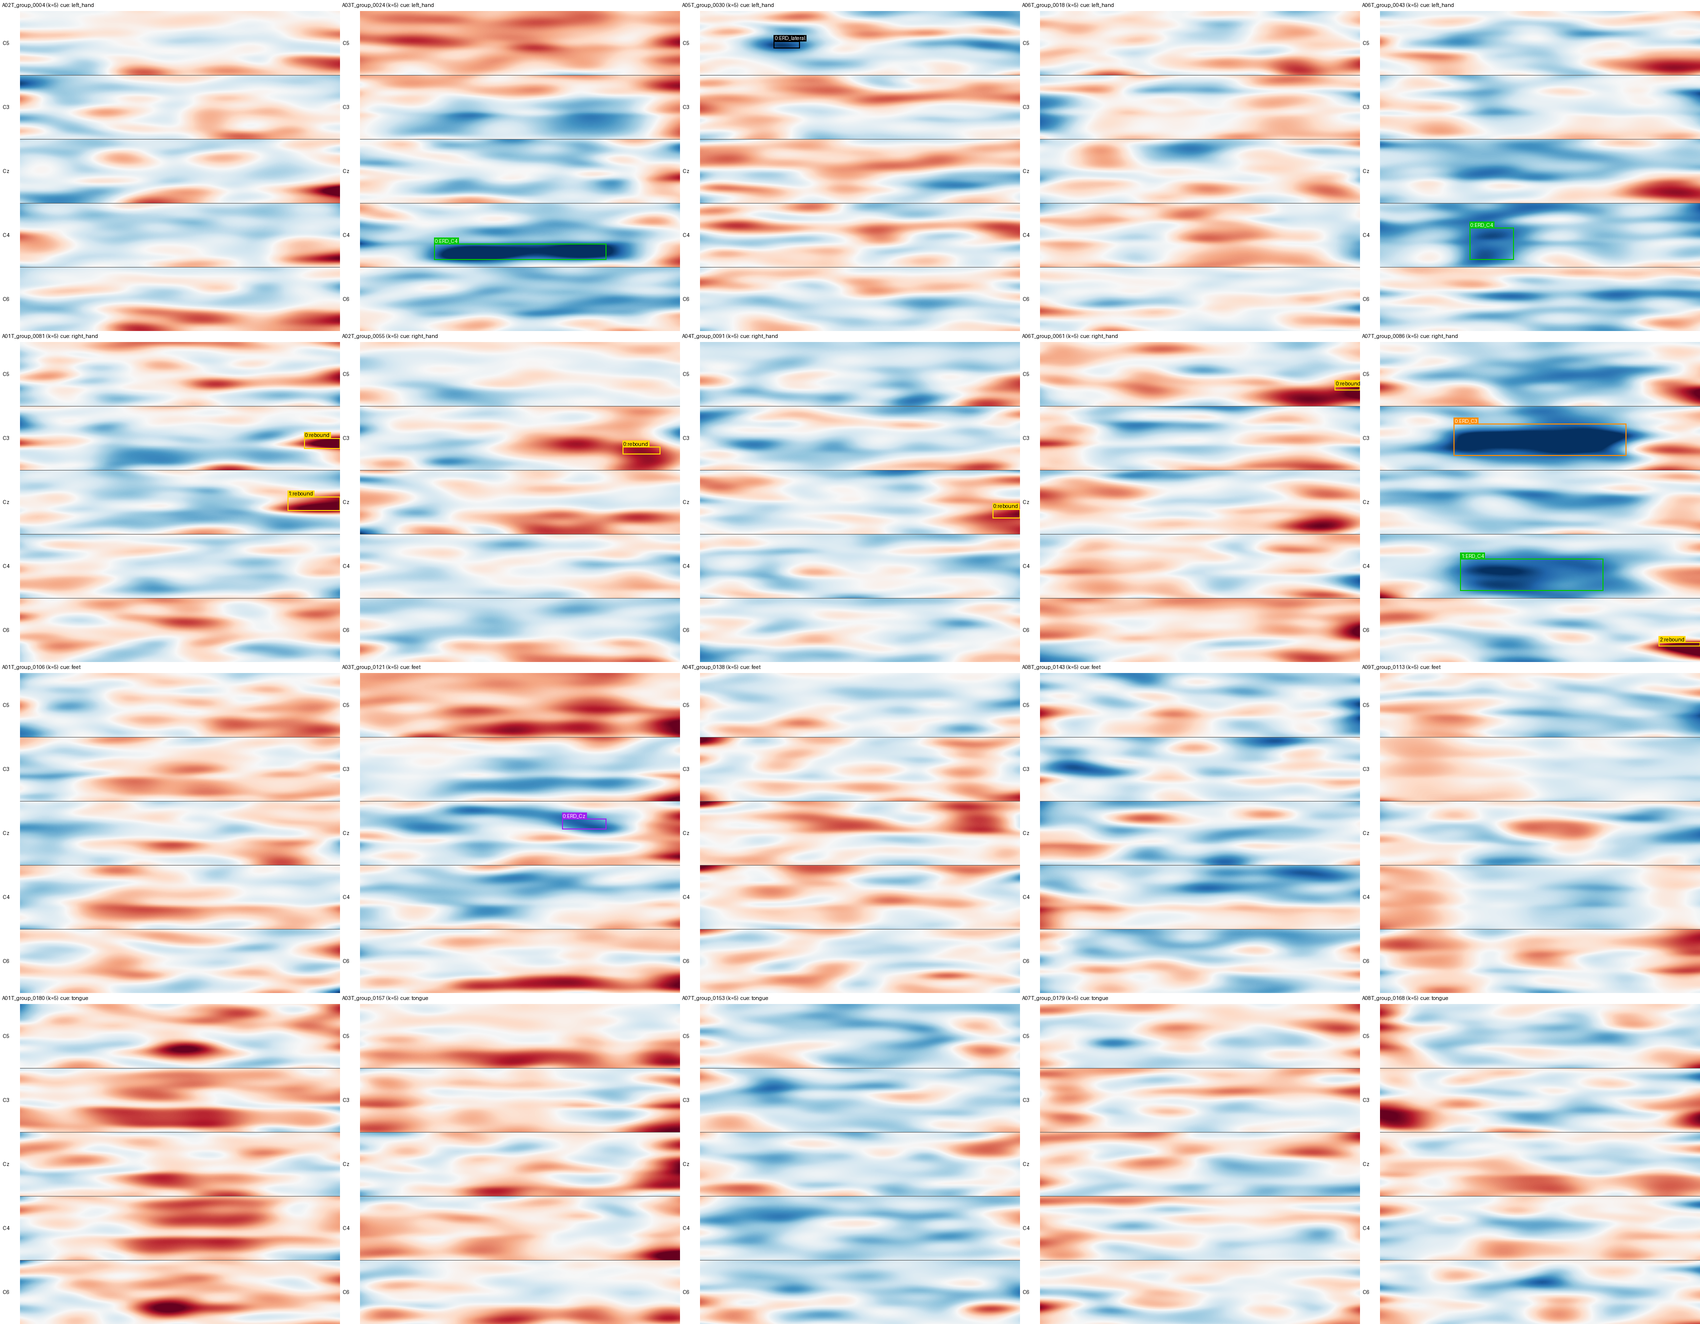

In [10]:
display(Image(filename=str(F / "kavg_examples.png"), width=1000))

### 3.1 Statistics

In [11]:
stats = pd.read_csv(T / "kavg_label_stats.csv")
s5 = stats[stats["dataset"] == "5class"]
display(s5.pivot_table(index="class_name", columns="split", values="n_boxes").reindex(columns=["train", "val", "test"]))
display(stats[stats["class_name"] == "all"][["dataset", "split", "n_images", "n_background", "background_pct"]]
        .set_index(["dataset", "split"]))
s5[(s5["split"] == "train") & (s5["class_name"] != "all")][
    ["class_name", "n_boxes", "dur_s_median", "dur_s_p10", "dur_s_p90", "bw_hz_median", "bw_hz_p10", "bw_hz_p90"]
].set_index("class_name")

split,train,val,test
class_name,,,
ERD_C3,307.0,61.0,345.0
ERD_C4,280.0,53.0,352.0
ERD_Cz,208.0,43.0,233.0
ERD_lateral,283.0,62.0,248.0
ERS_rebound,460.0,90.0,773.0
all,1538.0,309.0,1951.0


n_images  n_background  background_pct
dataset split                                        
5class  train      1800          1009           56.06
        val         360           206           57.22
        test       1800           913           50.72
2class  train       900           530           58.89
        val         180           115           63.89
        test        900           487           54.11

,n_boxes,dur_s_median,dur_s_p10,dur_s_p90,bw_hz_median,bw_hz_p10,bw_hz_p90
class_name,,,,,,,
ERD_C4,280,2.24,0.78,3.49,14.5,5.0,22.0
ERD_C3,307,2.36,0.70,3.50,16.0,4.0,22.0
ERD_Cz,208,1.11,0.59,2.29,5.0,2.7,9.0
ERD_lateral,283,0.97,0.58,1.87,5.0,2.0,10.0
ERS_rebound,460,0.75,0.55,1.21,5.0,2.0,10.0


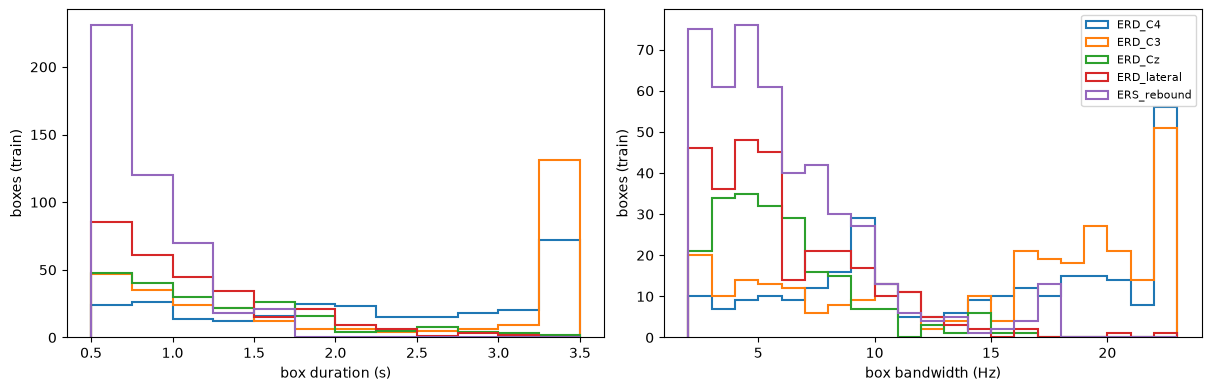

In [12]:
boxes = pd.read_csv(resolve(pcfg["paths"]["processed_dir"]) / "groups" / f"boxes_k{gcfg['k']}.csv")
kept = boxes[(boxes["status"] == "kept") & (boxes["split"] == "train")]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for c in CLASSES_5:
    b = kept[kept["class_name"] == c]
    axes[0].hist(b["t_off"] - b["t_on"], bins=np.arange(0.5, 3.7, 0.25), histtype="step", lw=1.5, label=c)
    axes[1].hist(b["f_high"] - b["f_low"], bins=np.arange(2, 24, 1), histtype="step", lw=1.5, label=c)
axes[0].set_xlabel("box duration (s)")
axes[1].set_xlabel("box bandwidth (Hz)")
for ax in axes:
    ax.set_ylabel("boxes (train)")
axes[1].legend(fontsize=8)
plt.savefig(F / "box_size_distributions.png", dpi=120)
plt.show()

### 3.2 Trial overlap between groups

Groups are distinct random 5-trial subsets of each subject × cue × split pool, so images share trials.
The validation pool is small (median 13 trials per subject and cue), which makes validation images strongly
correlated; differences between runs on validation must be read with care.

In [13]:
pd.read_csv(T / "kavg_group_overlap.csv").set_index("split")

,n_groups,n_unique,pool_min,pool_median,log10_possible_min,mean_pair_overlap,max_pair_overlap,uses_per_trial_mean
split,,,,,,,,
train,1800,1800,39,53.0,5.76,0.10,0.8,4.87
val,360,360,10,13.0,2.40,0.39,0.8,3.87
test,1800,1800,53,68.0,6.46,0.08,0.8,3.84


### 3.3 Agreement with the cue

The labels never see the cue, so agreement with it is an independent sanity check: for each group, does the
strongest ERD box sit on the panel that matches the cue (C4 ↔ left hand, C3 ↔ right hand, Cz ↔ feet,
C5/C6 ↔ tongue)? Groups without any ERD box count as no match. Chance is estimated by shuffling cues
among groups of the same subject, session, and split.

n_trials  no_erd_box_pct  strongest_match_pct  \
subject session                                                  
A01     E           200.0            72.0                 13.0   
        T           240.0            77.9                 10.0   
A02     E           200.0           100.0                  0.0   
        T           240.0           100.0                  0.0   
A03     E           200.0            46.5                 49.5   
        T           240.0            48.8                 49.6   
A04     E           200.0            90.5                  1.5   
        T           240.0            97.1                  1.2   
A05     E           200.0            95.5                  0.5   
        T           240.0            80.4                  5.0   
A06     E           200.0            78.5                 10.5   
        T           240.0            82.9                  7.5   
A07     E           200.0            21.0                 65.5   
        T           240.0            27.1                 45.4   
A08     E           200.0            58.0                 36.5   
        T           240.0            58.8                 20.8   
A09     E           200.0            51.5                 32.0   
        T           240.0            53.8                 33.8   
all     E          1800.0            68.2                 23.2   
        T          2160.0            69.6                 19.3   

                 strongest_match_pct_chance  
subject session                              
A01     E                               7.0  
        T                               5.3  
A02     E                               0.0  
        T                               0.0  
A03     E                              13.2  
        T                              12.9  
A04     E                               2.2  
        T                               0.8  
A05     E                               1.1  
        T                               4.8  
A06     E                               5.6  
        T                               4.3  
A07     E                              19.8  
        T                              18.7  
A08     E                              10.3  
        T                              10.2  
A09     E                              12.8  
        T                              11.7  
all     E                               8.0  
        T                               7.6

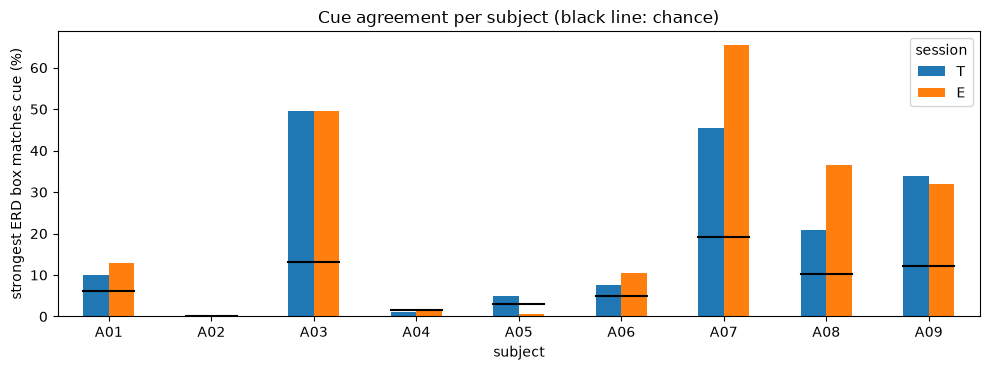

In [14]:
cm = pd.read_csv(T / "kavg_cue_match_by_subject.csv")
display(cm.set_index(["subject", "session"])[["n_trials", "no_erd_box_pct", "strongest_match_pct",
                                               "strongest_match_pct_chance"]])
per = cm[cm["subject"] != "all"].pivot(index="subject", columns="session", values="strongest_match_pct")
chance = cm[cm["subject"] != "all"].pivot(index="subject", columns="session", values="strongest_match_pct_chance")
ax = per[["T", "E"]].plot.bar(figsize=(10, 3.8), rot=0, color=["tab:blue", "tab:orange"])
for i, s in enumerate(per.index):
    ax.plot([i - 0.25, i + 0.25], [chance.loc[s].mean()] * 2, color="k", lw=1.5)
ax.set_ylabel("strongest ERD box matches cue (%)")
ax.set_title("Cue agreement per subject (black line: chance)")
plt.tight_layout()
plt.savefig(F / "cue_agreement_by_subject.png", dpi=120)
plt.show()

Subjects differ strongly. A03, A07, A08, and A09 show clear, mostly contralateral ERD; A02 yields no ERD
box at all, and A04 and A05 are close to chance. This mirrors the well-known *BCI inefficiency*: a fraction of
users does not produce a measurable sensorimotor rhythm modulation.

## 4. Manual quality check

50 random training images with at least one box (98 boxes) were reviewed on annotated overlays
(`results/qc/*.png`: time axis, frequency ticks per panel, cue and end-of-imagery lines, box list). Each box
got a verdict (*valid*: a coherent ERD/ERS of the right type, band, and time window; *unsure*; *invalid*)
and an extent rating (*good*: the box matches the visible event; *partial*: it covers only the strongest core;
*clipped*: cut by the band or window limits of the rule). A first pass was pre-filled by Claude Code
(`verdict_pass1`) and then checked and corrected by the authors (`verdict`).

In [15]:
qc = pd.read_csv(resolve("results/qc/qc_sheet.csv"), keep_default_na=False)
counts = qc.groupby("class")["verdict"].value_counts().unstack(fill_value=0).reindex(columns=["valid", "unsure", "invalid"], fill_value=0)
counts.loc["all"] = counts.sum()
counts["valid_pct"] = (100 * counts["valid"] / counts[["valid", "unsure", "invalid"]].sum(axis=1)).round(1)
display(counts)
display(qc.groupby("class")["extent"].value_counts().unstack(fill_value=0))
display(pd.crosstab(qc["verdict_pass1"], qc["verdict"], margins=True))

verdict,valid,unsure,invalid,valid_pct
class,,,,
ERD_C3,20,1,0,95.2
ERD_C4,17,1,0,94.4
ERD_Cz,15,1,0,93.8
ERD_lateral,14,7,0,66.7
ERS_rebound,15,4,3,68.2
all,81,14,3,82.7


extent,clipped,good,n/a,partial
class,,,,
ERD_C3,5,12,0,4
ERD_C4,4,11,0,3
ERD_Cz,1,8,0,7
ERD_lateral,4,6,0,11
ERS_rebound,6,7,3,6


verdict,invalid,unsure,valid,All
verdict_pass1,,,,
unsure,3,14,12,29
valid,0,0,69,69
All,3,14,81,98


In [16]:
qc[qc["verdict"] != "valid"][["image", "box_idx", "class", "verdict", "extent", "note"]]

,image,box_idx,class,verdict,extent,note
0,A01T_group_0020.png,0,ERS_rebound,unsure,clipped,increase starts ~3.3 s and peaks around 4 s; u...
1,A01T_group_0020.png,1,ERD_lateral,unsure,partial,"thin box on a diffuse, weak C6 decrease"
2,A01T_group_0029.png,0,ERS_rebound,invalid,n/a,broadband increase up to 40 Hz on several pane...
3,A01T_group_0029.png,1,ERD_lateral,unsure,clipped,decrease is mostly above 30 Hz; box is a slive...
4,A01T_group_0029.png,2,ERS_rebound,invalid,n/a,broadband increase up to 40 Hz on several pane...
18,A03T_group_0175.png,0,ERD_Cz,unsure,clipped,decrease is mostly above 30 Hz and strongest a...
23,A04T_group_0108.png,0,ERS_rebound,unsure,good,"compact patch, but a similar increase in the s..."
29,A06T_group_0129.png,0,ERS_rebound,unsure,clipped,increase is mainly <13 Hz and starts at ~3.5 s...
30,A06T_group_0165.png,0,ERS_rebound,invalid,n/a,broadband increase up to 40 Hz on several pane...
31,A06T_group_0167.png,0,ERS_rebound,unsure,clipped,alpha increase already present from 2.5 s; box...


Most boxes mark a real event: the hand and midline classes (`ERD_C4`, `ERD_C3`, `ERD_Cz`) are almost all
valid. The weak spots are `ERD_lateral` (thin boxes on diffuse C5/C6 decreases) and `ERS_rebound`, whose
invalid boxes are broadband increases up to 40 Hz at the end of the epoch on several panels, more likely
muscle or movement artifacts than a beta rebound. Box extent is the main limitation: less than half of the
boxes match the visible event (*good*); the z ≥ 3 rule tends to box only the strongest core of a larger
region, or the box is clipped at 30 Hz or at the 4 s / 5.5 s window limits. This bounds how much
mAP@0.5:0.95 can be interpreted as physiological localization accuracy.